<h1> Geometric Operations and Other Mathematical Tools</h1>


Estimated time needed: **40** minutes


<h2>Objectives</h2>


In the first part of the lab, you will apply geometric transformations to an image. This allows you to perform different operations like reshape translation i.e. to shift, reshape and rotate the image. In the second part of the lab, you will learn how to apply some basic array and matrix operations to the image. 


<ul>
    <li><a href='#PT'> Geometric Operations  </a>
        <ul>
            <li>Scaling  </li>
            <li>Translation</li>
            <li>Rotation</li>   
          </ul>
        <li><a href='#PT'>  Mathematical Operations   </a>
        <ul>
            <li>Array Operations  </li>
            <li>Matix Operations n</li> 
          </ul>


</ul>


----


Download the image for the lab:


In [1]:
!curl "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png" -O lenna.png
!curl "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png" -O baboon.png
!curl "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png" -O barbara.png  

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
 13  462k   13 65536    0     0  34819      0  0:00:13  0:00:01  0:00:12 34859
100  462k  100  462k    0     0   186k      0  0:00:02  0:00:02 --:--:--  187k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0curl: (6) Could not resolve host: lenna.png
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0   

We will import the following:


In [2]:
import matplotlib.pyplot as plt  # thư viện để vẽ biểu đồ và hiển thị ảnh
import cv2  # thư viện opencv để xử lý ảnh và thực hiện các phép biến đổi hình học
import numpy as np  # thư viện tính toán số học với mảng đa chiều

First, let's define a helper function to plot two images side-by-side. You will not need to understand this code this moment, but this function will be used repeatedly in this tutorial to showcase the results. 


In [3]:
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):  # định nghĩa hàm để hiển thị hai ảnh cạnh nhau
    plt.figure(figsize=(10,10))  # tạo khung hình với kích thước 10x10 inch
    plt.subplot(1, 2, 1)  # chia khung thành 1 hàng 2 cột và chọn ô đầu tiên
    plt.imshow(image_1,cmap="gray")  # hiển thị ảnh đầu tiên với bảng màu xám
    plt.title(title_1)  # đặt tiêu đề cho ảnh đầu tiên
    plt.subplot(1, 2, 2)  # chọn ô thứ hai trong khung đã chia
    plt.imshow(image_2,cmap="gray")  # hiển thị ảnh thứ hai với bảng màu xám
    plt.title(title_2)  # đặt tiêu đề cho ảnh thứ hai
    plt.show()  # hiển thị toàn bộ khung hình ra màn hình

#  Geometric Transformations


 Geometric transformations allow you to perform different operations like translation i.e. to shift, reshape and rotate the image.


## Scaling 


We can resize an image using the function `resize()` from `cv2` module for this purpose.  You can specify the scaling factor or the size of the image:


Consider the following image with the corresponding intensity values:


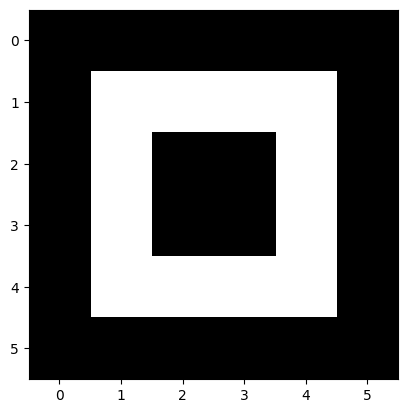

array([[  0.,   0.,   0.,   0.,   0.,   0.],
       [  0., 255., 255., 255., 255.,   0.],
       [  0., 255.,   0.,   0., 255.,   0.],
       [  0., 255.,   0.,   0., 255.,   0.],
       [  0., 255., 255., 255., 255.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.]])

In [4]:
toy_image = np.zeros((6,6))  # tạo mảng ảnh mẫu kích thước 6x6 toàn số không màu đen
toy_image[1:5,1:5]=255  # đặt giá trị 255 màu trắng cho vùng từ hàng 1 đến 4 và cột 1 đến 4
toy_image[2:4,2:4]=0  # đặt lại giá trị 0 màu đen cho vùng từ hàng 2 đến 3 và cột 2 đến 3 để tạo hình vuông rỗng
plt.imshow(toy_image,cmap='gray')  # hiển thị ảnh mẫu với bảng màu xám
plt.show()  # vẽ ảnh ra màn hình
toy_image  # hiển thị giá trị của mảng ảnh mẫu

We can rescale along a specific axis:

- `fx`: scale factor along the horizontal axis  
- `fy`: scale factor along the vertical axis


The parameter interpolation estimates pixel values based on neighboring pixels. <code>INTER_NEAREST</code> uses the nearest pixel and <code>INTER_CUBIC</code> uses several pixels near the pixel value we would like to estimate.


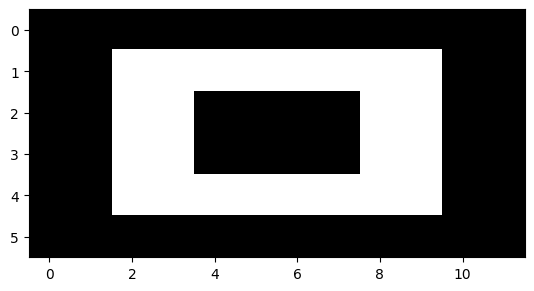

In [5]:
new_toy = cv2.resize(toy_image,None,fx=2, fy=1, interpolation = cv2.INTER_NEAREST )  # thay đổi kích thước ảnh mẫu với hệ số phóng đại ngang 2 lần dọc giữ nguyên và dùng phương pháp nội suy điểm gần nhất
plt.imshow(new_toy,cmap='gray')  # hiển thị ảnh đã được thay đổi kích thước với bảng màu xám
plt.show()  # vẽ ảnh ra màn hình


Consider the following image:


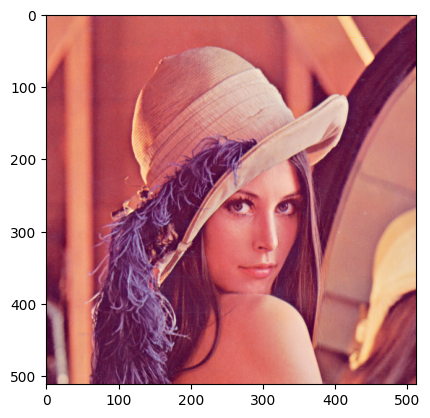

In [6]:
image = cv2.imread("lenna.png")  # đọc file ảnh lenna.png bằng opencv và lưu vào biến image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ định dạng BGR sang RGB rồi hiển thị vì opencv đọc ảnh theo định dạng BGR còn matplotlib hiển thị theo RGB
plt.show()  # vẽ ảnh ra màn hình

We can scale the horizontal axis by two and leave the vertical axis as is:


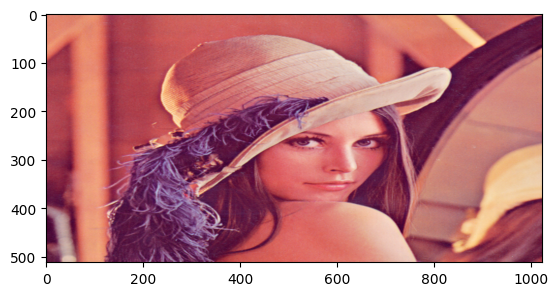

old image shape: (512, 512, 3) new image shape: (512, 1024, 3)


In [7]:
new_image = cv2.resize(image, None, fx=2, fy=1, interpolation=cv2.INTER_CUBIC)  # thay đổi kích thước ảnh với hệ số phóng đại ngang 2 lần dọc giữ nguyên và dùng phương pháp nội suy cubic để có chất lượng tốt hơn
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình
print("old image shape:", image.shape, "new image shape:", new_image.shape)  # in ra kích thước của ảnh cũ và ảnh mới để so sánh

In the same manner, we can scale the vertical axis by two:


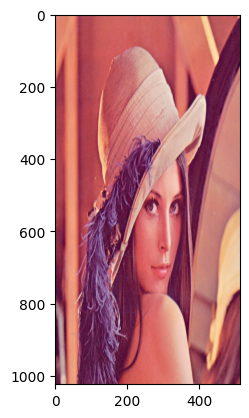

old image shape: (512, 512, 3) new image shape: (1024, 512, 3)


In [8]:
new_image = cv2.resize(image, None, fx=1, fy=2, interpolation=cv2.INTER_CUBIC)  # thay đổi kích thước ảnh với hệ số phóng đại ngang giữ nguyên dọc tăng 2 lần và dùng phương pháp nội suy cubic
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình
print("old image shape:", image.shape, "new image shape:", new_image.shape)  # in ra kích thước của ảnh cũ và ảnh mới để so sánh

We can scale the horizontal axis and vertical axis by two.


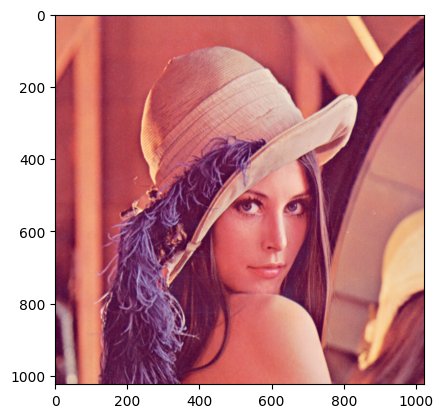

old image shape: (512, 512, 3) new image shape: (1024, 1024, 3)


In [9]:
new_image = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)  # thay đổi kích thước ảnh với hệ số phóng đại cả ngang và dọc đều tăng 2 lần và dùng phương pháp nội suy cubic
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình
print("old image shape:", image.shape, "new image shape:", new_image.shape)  # in ra kích thước của ảnh cũ và ảnh mới để so sánh

We can also shrink the image by setting the scaling factor to a real number between 0 and 1:


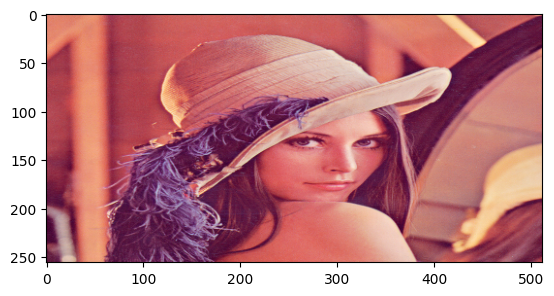

old image shape: (512, 512, 3) new image shape: (256, 512, 3)


In [10]:
new_image = cv2.resize(image, None, fx=1, fy=0.5, interpolation=cv2.INTER_CUBIC)  # thay đổi kích thước ảnh với hệ số ngang giữ nguyên dọc giảm một nửa và dùng phương pháp nội suy cubic
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình
print("old image shape:", image.shape, "new image shape:", new_image.shape)  # in ra kích thước của ảnh cũ và ảnh mới để so sánh

We can  also specify the number of rows and columns:


In [11]:
rows = 100  # đặt số hàng của ảnh mới là 100
cols = 200  # đặt số cột của ảnh mới là 200

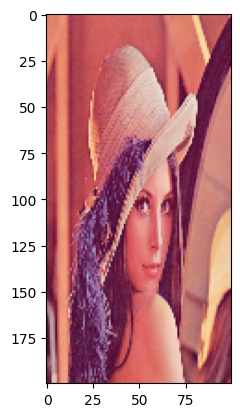

old image shape: (512, 512, 3) new image shape: (200, 100, 3)


In [12]:
new_image = cv2.resize(image, (100, 200), interpolation=cv2.INTER_CUBIC)  # thay đổi kích thước ảnh về kích thước cụ thể chiều rộng 100 chiều cao 200 và dùng phương pháp nội suy cubic
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình
print("old image shape:", image.shape, "new image shape:", new_image.shape)  # in ra kích thước của ảnh cũ và ảnh mới để so sánh

## Translation


Translation is  when you  shift the location of the image. <code>tx</code> is the number of pixels you shift the location in the horizontal direction and <code>ty</code> is the number of pixels you shift in the vertical direction. You can create the transformation matrix $M$ to shift the image. 

In this example, we shift the image 100 pixels horizontally:


In [13]:
tx = 100  # đặt độ dịch chuyển theo chiều ngang là 100 pixel
ty = 0  # đặt độ dịch chuyển theo chiều dọc là 0 pixel
M = np.float32([[1, 0, tx], [0, 1, ty]])  # tạo ma trận biến đổi affine để dịch chuyển ảnh với các giá trị dịch chuyển đã định nghĩa
M  # hiển thị ma trận biến đổi

array([[  1.,   0., 100.],
       [  0.,   1.,   0.]], dtype=float32)

The shape of the image is given by:


In [14]:
rows, cols, _ = image.shape  # lấy số hàng số cột và số kênh màu của ảnh dấu gạch dưới bỏ qua số kênh màu

We use the function <code>warpAffine</code> from the <code>cv2</code> module. The first input parater is an image array, the second input parameter is the transformation matrix <code>M</code>, and the final input paramter is the length and width of the output image $(cols,rows)$:


In [15]:
new_image = cv2.warpAffine(image, M, (cols, rows))  # áp dụng phép biến đổi affine để dịch chuyển ảnh với ma trận M và kích thước đầu ra là cols hàng rows cột

We can plot the image; the portions of the image that do not have any intensities are set to zero:


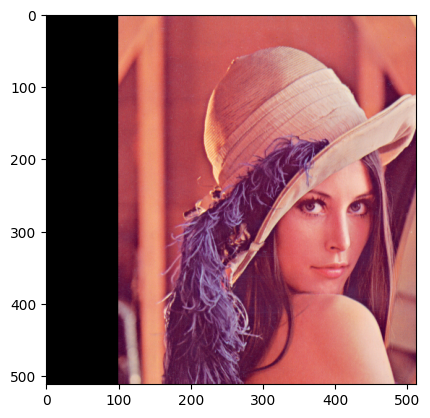

In [16]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình

We can see some of the original image has been cut off. We can fix this by changing the output image size: <code>(cols + tx,rows + ty)</code>:


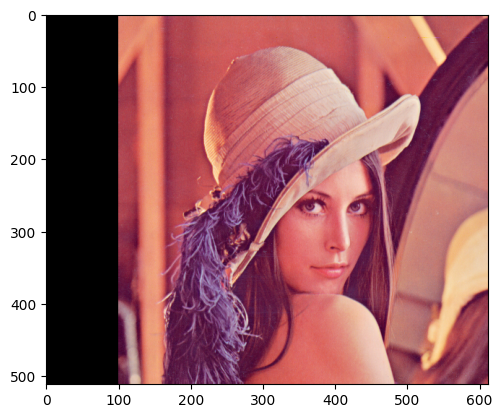

In [17]:
new_image = cv2.warpAffine(image, M, (cols + tx, rows + ty))  # áp dụng phép biến đổi affine với kích thước đầu ra được mở rộng để không bị cắt mất phần ảnh khi dịch chuyển
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình

We can shift the image horizontally:


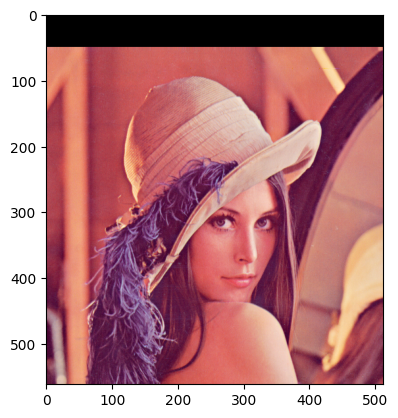

In [18]:
tx = 0  # đặt độ dịch chuyển theo chiều ngang là 0 pixel
ty = 50  # đặt độ dịch chuyển theo chiều dọc là 50 pixel
M = np.float32([[1, 0, tx], [0, 1, ty]])  # tạo ma trận biến đổi affine để dịch chuyển ảnh theo chiều dọc
new_iamge = cv2.warpAffine(image, M, (cols + tx, rows + ty))  # áp dụng phép biến đổi affine để dịch chuyển ảnh xuống dưới với kích thước đầu ra được mở rộng
plt.imshow(cv2.cvtColor(new_iamge, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình

## Rotation 


We can rotate an image by angle θ which is achieved by the Rotation Matrix <code>getRotationMatrix2D</code>.


<p><code>center</code>: Center of the rotation in the source image. We will only use the center of the image.</p>
<p><code>angle</code>: Rotation angle in degrees. Positive values mean counter-clockwise rotation (the coordinate origin is assumed to be the top-left corner).</p>
<p><code>scale</code>: Isotropic scale factor, in this course the value will be one.</p>


We can rotate our toy image by 45 degrees:


In [19]:
theta = 45.0  # đặt góc quay là 45 độ
M = cv2.getRotationMatrix2D(center=(3, 3), angle=theta, scale=1)  # tạo ma trận quay với tâm quay tại điểm 3 3 góc quay 45 độ và tỷ lệ giữ nguyên
new_toy_image = cv2.warpAffine(toy_image, M, (6, 6))  # áp dụng phép biến đổi affine để xoay ảnh mẫu với ma trận quay đã tạo và kích thước đầu ra 6x6

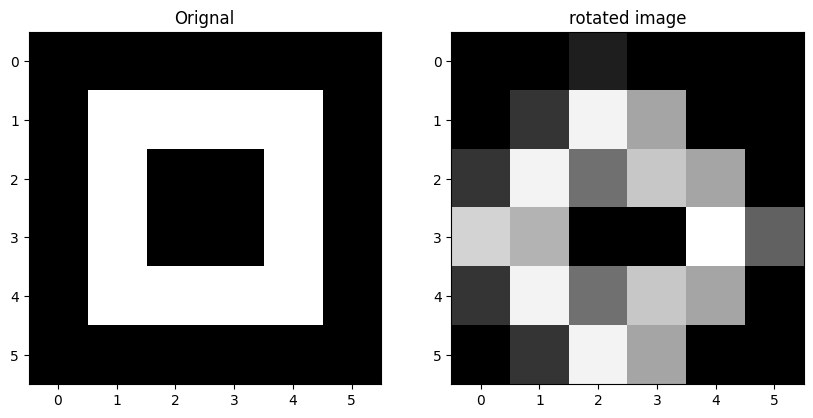

In [20]:
plot_image(toy_image, new_toy_image, title_1="Orignal", title_2="rotated image")  # hiển thị ảnh gốc và ảnh đã xoay cạnh nhau bằng hàm plot_image

Looking at intensity values, we see that many values have been interpolated:


In [21]:
new_toy_image 

array([[  0.        ,   0.        ,  28.38867188,   0.        ,
          0.        ,   0.        ],
       [  0.        ,  47.8125    , 223.125     , 151.40625   ,
          0.        ,   0.        ],
       [ 47.8125    , 223.125     , 103.59375   , 183.28125   ,
        151.40625   ,   0.        ],
       [195.234375  , 165.10253906,   0.        ,   0.        ,
        234.82910156,  89.89746094],
       [ 47.8125    , 223.125     , 103.59375   , 183.28125   ,
        151.40625   ,   0.        ],
       [  0.        ,  47.8125    , 223.125     , 151.40625   ,
          0.        ,   0.        ]])

We can perform the same operation on color images:


In [22]:
cols, rows, _ = image.shape  # lấy số cột số hàng và số kênh màu của ảnh dấu gạch dưới bỏ qua số kênh màu

In [23]:
M = cv2.getRotationMatrix2D(center=(cols // 2 - 1, rows // 2 - 1), angle=theta, scale=1)  # tạo ma trận quay với tâm quay tại trung tâm ảnh góc quay theta và tỷ lệ giữ nguyên
new_image = cv2.warpAffine(image, M, (cols, rows))  # áp dụng phép biến đổi affine để xoay ảnh với ma trận quay đã tạo và kích thước đầu ra giữ nguyên

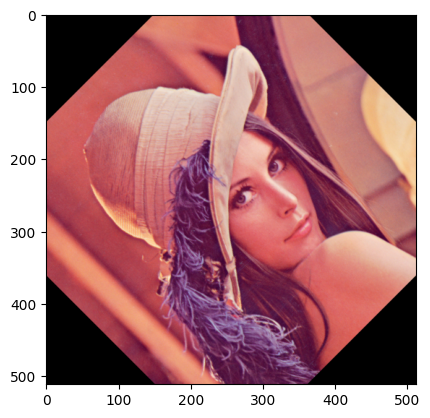

In [24]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình

# Mathematical Operations 


## Array Operations 


We can perform array operations on an image; Using Python broadcasting, we can add a constant to each pixel's intensity value. 


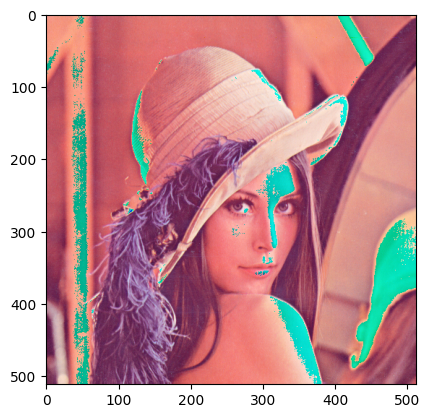

In [25]:
new_image = image + 20  # cộng thêm 20 vào giá trị cường độ của mỗi điểm ảnh để làm sáng ảnh

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình

We can also multiply every pixel's intensity value by a constant value.


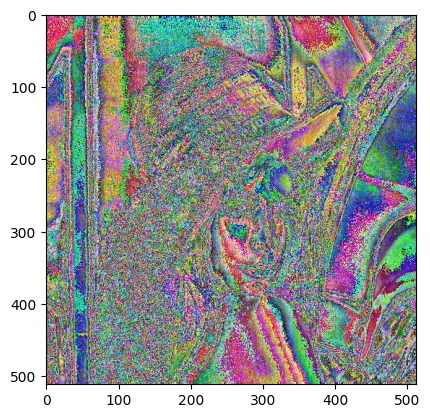

In [26]:
new_image = 10 * image  # nhân giá trị cường độ của mỗi điểm ảnh với 10 để tăng độ sáng mạnh hơn
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình

We can add the elements of two arrays of equal shape. In this example, we generate an array of random noises with the same shape and data type as our image.


In [27]:
Noise = np.random.normal(0, 20, (rows, cols, 3)).astype(np.uint8)  # tạo mảng nhiễu ngẫu nhiên với phân phối chuẩn trung bình 0 độ lệch chuẩn 20 và cùng kích thước với ảnh có 3 kênh màu rồi chuyển sang kiểu uint8
Noise.shape  # kiểm tra kích thước của mảng nhiễu vừa tạo


(512, 512, 3)

We add the generated noise to the image and plot the result. We see the values that have corrupted the image:


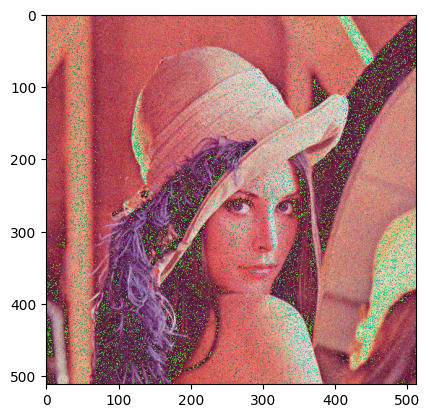

In [28]:
new_image = image + Noise  # cộng mảng nhiễu vào ảnh gốc để tạo hiệu ứng nhiễu

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình

At the same time, we can multiply the elements of two arrays of equal shape. We can multiply the random image and the Lenna image and plot the result. 


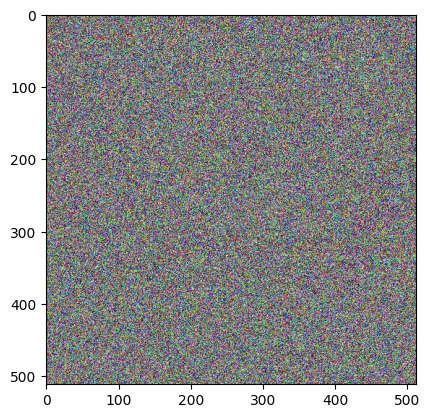

In [29]:
new_image = image*Noise  # nhân từng phần tử của ảnh với từng phần tử tương ứng của mảng nhiễu

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))  # chuyển đổi ảnh từ BGR sang RGB rồi hiển thị
plt.show()  # vẽ ảnh ra màn hình

## Matrix Operations 


Grayscale images are matrices. Consider the following grayscale image:


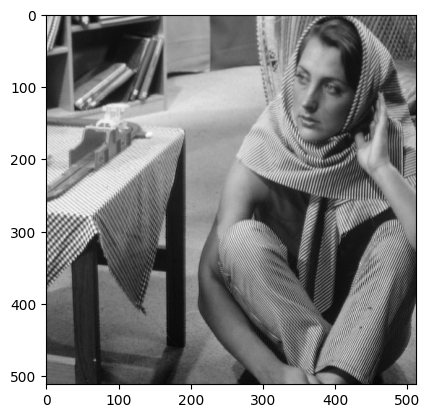

In [30]:
im_gray = cv2.imread('barbara.png', cv2.IMREAD_GRAYSCALE)  # đọc file ảnh barbara.png ở chế độ ảnh xám và lưu vào biến im_gray
im_gray.shape  # kiểm tra kích thước của ảnh xám

plt.imshow(im_gray,cmap='gray')  # hiển thị ảnh xám với bảng màu xám
plt.show()  # vẽ ảnh ra màn hình

We can apply algorithms designed for matrices.  We can use  Singular Value Decomposition, decomposing our image matrix into  a product of three matrices.


In [31]:
U, s, V = np.linalg.svd(im_gray , full_matrices=True)  # phân tích svd để tách ma trận ảnh thành ba ma trận U s và V với full_matrices cho phép tạo ma trận đầy đủ

We see <code>s</code> is not rectangular:


In [32]:
s.shape  # kiểm tra kích thước của vector s chứa các giá trị đặc trưng

(512,)

We can convert  <code>s</code> to a diagonal matrix <code>S</code>:


In [33]:
S = np.zeros((im_gray.shape[0], im_gray.shape[1]))  # tạo ma trận S toàn số không với cùng kích thước như ảnh xám
S[:im_gray.shape[0], :im_gray.shape[0]] = np.diag(s)  # đặt các giá trị đường chéo từ vector s vào ma trận S để tạo ma trận đường chéo


We can plot the matrix `U` and `V`:


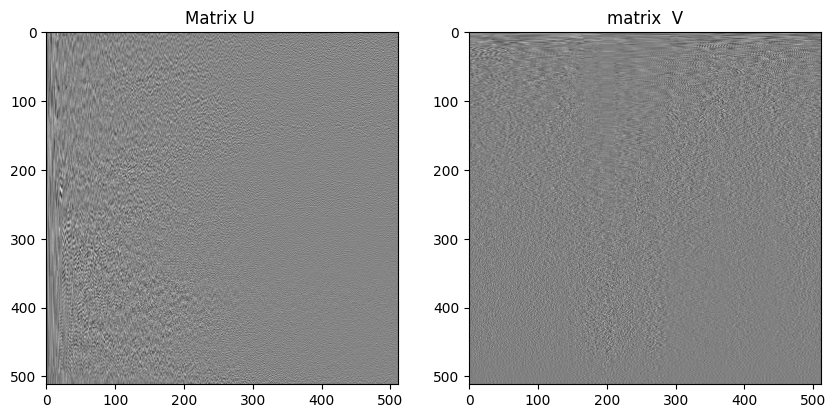

In [34]:
 plot_image(U,V,title_1="Matrix U ",title_2="matrix  V")  # hiển thị hai ma trận U và V cạnh nhau bằng hàm plot_image đã định nghĩa

We see most of the elements in `S` are zero:


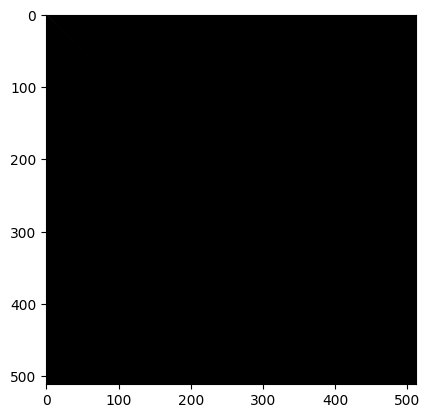

In [35]:
plt.imshow(S,cmap='gray')  # hiển thị ma trận S với bảng màu xám để xem các giá trị đường chéo
plt.show()  # vẽ ma trận ra màn hình

We can find the matrix product of all the matrices. First, we can perform matrix multiplication on `S` and `U` and assign it  to `B` and plot the results: 


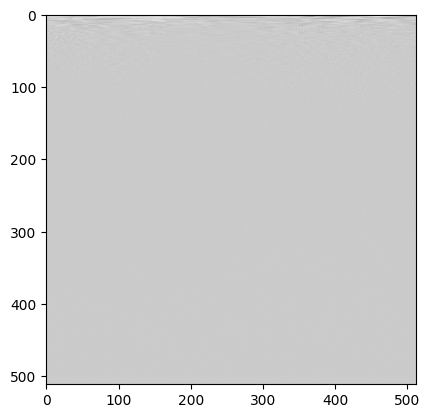

In [36]:
B = S.dot(V)  # nhân ma trận S với ma trận V để tạo ma trận trung gian B
plt.imshow(B,cmap='gray')  # hiển thị kết quả ma trận B với bảng màu xám
plt.show()  # vẽ ma trận B ra màn hình

We can find the matrix product of `U`, `S`, and `B`. We see it’s the entire image:


In [37]:
A = U.dot(B)  # nhân ma trận U với ma trận B để khôi phục lại ảnh gốc từ các thành phần đã phân tích

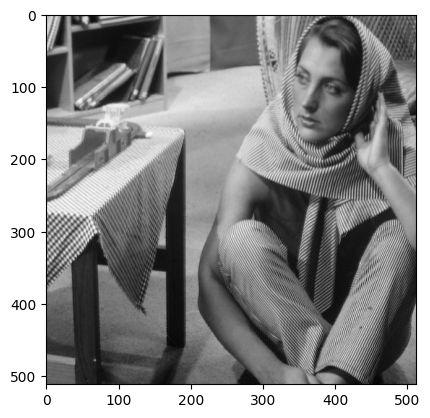

In [38]:
plt.imshow(A,cmap='gray')  # hiển thị ảnh đã được khôi phục từ các ma trận phân tích
plt.show()  # vẽ ảnh khôi phục ra màn hình

It turns out many elements are redundant, so we can eliminate some rows and columns of `S` and `V` and approximate the image by finding the product.


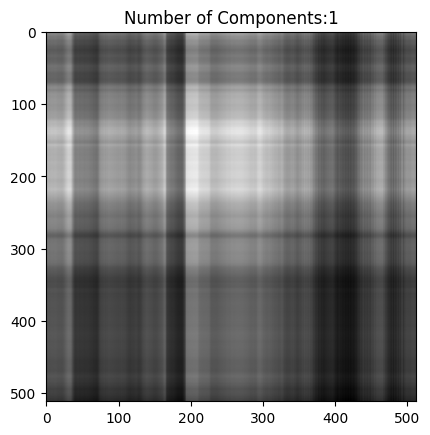

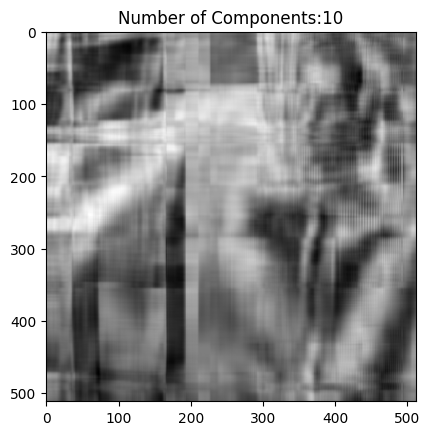

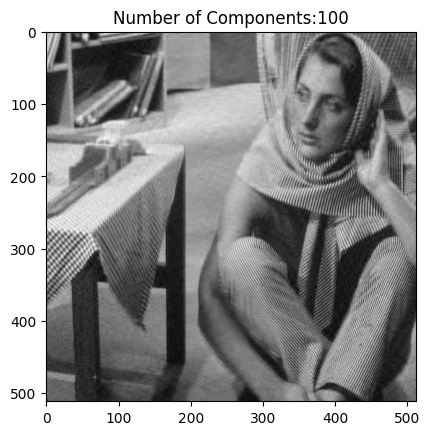

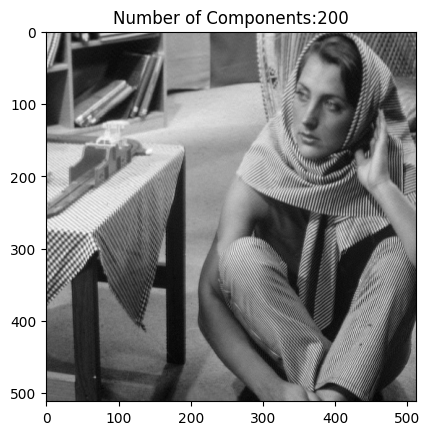

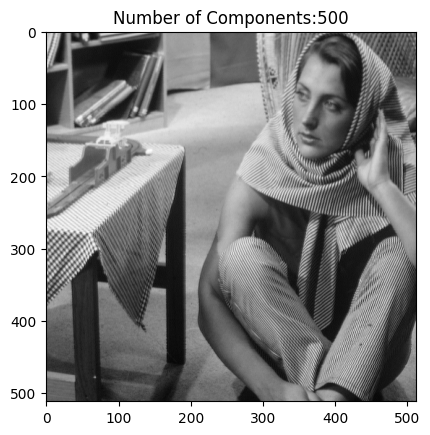

In [39]:
for n_component in [1,10,100,200, 500]:  # lặp qua các số thành phần khác nhau để xem chất lượng ảnh khi giảm số thành phần
    S_new = S[:, :n_component]  # lấy n_component cột đầu tiên của ma trận S để giảm số thành phần
    V_new = V[:n_component, :]  # lấy n_component hàng đầu tiên của ma trận V để giảm số thành phần
    A = U.dot(S_new.dot(V_new))  # nhân lại ba ma trận để tạo ảnh xấp xỉ với số thành phần đã giảm
    plt.imshow(A,cmap='gray')  # hiển thị ảnh xấp xỉ với bảng màu xám
    plt.title("Number of Components:"+str(n_component))  # đặt tiêu đề cho ảnh với số thành phần đang sử dụng
    plt.show()  # vẽ ảnh xấp xỉ ra màn hình

We see we only need 100 to 200 Components to represent the image.


# References 


[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.


<!--<h2>Change Log</h2>-->


<!--
<table>
    <tr>
        <th>Date (YYYY-MM-DD)</th>
        <th>Version</th>
        <th>Changed By</th>
        <th>Change Description</th>
    </tr>
    <tr>
        <td>2020-07-20</td>
        <td>0.2</td>
        <td>Azim</td>
        <td>Modified Multiple Areas</td>
    </tr>
    <tr>
        <td>2020-07-17</td>
        <td>0.1</td>
        <td>Azim</td>
        <td>Created Lab Template</td>
    </tr>
</table>
-->



<h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
